# Zero Shot Unroll On Regular Mesh

Notebook minimal pour evaluer un checkpoint existant en zero-shot sur le dataset regulier projete.

Flux :
- charger le dataset regulier projete
- reutiliser les statistiques du checkpoint
- evaluer l'unrolling sur toutes les sequences test
- moyenner l'erreur absolue sur `h` aux horizons horaires


In [1]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "python" / "create_dgl_dataset.py").exists():
            return path
    raise RuntimeError("Cannot find gnn_modulus_test project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ
from python.eval_rollout import (
    build_model,
    build_rollout_context,
    create_rollout_state,
    denormalize_state,
    load_model_checkpoint,
    rollout_step,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
MODEL_CONFIG = {
    "name": "paper_checkpoint",
    "ckpt_dir": "/work/m24046/m24046mrcr/Test_Tet_regular/checkpoints/config_transfer_Tet_regular/Seed0/",
    "epoch": 1050,
    "use_q_feature": True,
    "mesh": "full_flood",
    "num_input_features": 10,
    "num_output_features": 3,
    "num_edge_features": 3,
    "mp_layers": 10,
    "do_concat_trick": True,
    "num_processor_checkpoint_segments": 0,
    "dt_seconds": 1800.0,
}

REGULAR_BASE_BIN = "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_base.bin"
REGULAR_DYNAMIC_DIR = Path("/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short")
HYDRO_DIR = Path("/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes")

TEST_EVENTS = [
    "Group_1_peak_2600",
    "Group_2_peak_1000",
    "Group_2_peak_1200",
    "Group_2_peak_1600",
    "Group_4_peak_2000",
    "Group_1_peak_1200",
    "Group_1_peak_2400",
    "Group_3_peak_3400",
]

REQUESTED_MAX_HOURS = 40
MAX_SEQUENCES = 205
FIGSIZE = (7, 4)
DT_SECONDS = MODEL_CONFIG["dt_seconds"]
HOUR_IN_STEPS = max(1, int(round(3600.0 / DT_SECONDS)))


def build_regular_dynamic_path(event_name):
    short_name = event_name.replace("Group_", "G").replace("_peak_", "_P")
    return REGULAR_DYNAMIC_DIR / f"regular_50_dataset_{short_name}_0_35-64.pkl"


def build_hydro_path(event_name):
    return HYDRO_DIR / f"generated_hydrographs_{event_name}.liq"


In [3]:
def require_existing(path_like, label):
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"{label} introuvable: {path}")
    return path


def get_dynamic_length(file_path):
    with open(file_path, "rb") as f:
        return len(pickle.load(f))


def build_dataset(sequence_length, overlap=1):
    base_kwargs = {
        "data_dir": str(regular_base_path),
        "dynamic_data_files": [str(path) for path in dynamic_files],
        "split": "test",
        "ckpt_path": str(ckpt_dir),
        "normalize": True,
        "sequence_length": sequence_length,
        "overlap": overlap,
    }

    if MODEL_CONFIG["use_q_feature"]:
        return TelemacDatasetWithQ(
            name="regular_unroll_q",
            hydro_data_files=[str(path) for path in hydro_files],
            dt_seconds=DT_SECONDS,
            **base_kwargs,
        )

    return TelemacDataset(name="regular_unroll", **base_kwargs)


regular_base_path = require_existing(REGULAR_BASE_BIN, "REGULAR_BASE_BIN")
ckpt_dir = require_existing(MODEL_CONFIG["ckpt_dir"], "CKPT_DIR")
dynamic_files = [
    require_existing(build_regular_dynamic_path(event_name), f"DYNAMIC_FILE[{event_name}]")
    for event_name in TEST_EVENTS
]

hydro_files = []
if MODEL_CONFIG["use_q_feature"]:
    hydro_files = [
        require_existing(build_hydro_path(event_name), f"HYDRO_FILE[{event_name}]")
        for event_name in TEST_EVENTS
    ]

    if len(hydro_files) != len(dynamic_files):
        raise ValueError(
            f"Nombre de hydro_files ({len(hydro_files)}) different du nombre de dynamic_files ({len(dynamic_files)})."
        )

dynamic_lengths = [get_dynamic_length(path) for path in dynamic_files]
min_num_samples = min(dynamic_lengths)
max_available_step = max(1, min_num_samples - 1)
available_max_hours = max_available_step // HOUR_IN_STEPS

if available_max_hours < 1:
    raise ValueError("Aucun horizon horaire disponible avec les fichiers dynamiques courants.")

if available_max_hours < REQUESTED_MAX_HOURS:
    print(
        f"Attention: au moins un fichier test ne contient que {min_num_samples} echantillons. "
        f"Le notebook evaluera donc {available_max_hours} heures au lieu de {REQUESTED_MAX_HOURS}."
    )

MAX_HOURS = available_max_hours
HORIZONS_STEPS = [h * HOUR_IN_STEPS for h in range(1, MAX_HOURS + 1)]
SEQUENCE_LENGTH = max(HORIZONS_STEPS) + 1

print("model:", MODEL_CONFIG["name"])
print("ckpt dir:", ckpt_dir)
print("normalization:", "split=\"test\" + ckpt_path=checkpoint")
print("use_q_feature:", MODEL_CONFIG["use_q_feature"])
print("regular base:", regular_base_path)
print("events:", TEST_EVENTS)
print("min_num_samples:", min_num_samples)
print("max_hours:", MAX_HOURS)
print("sequence_length:", SEQUENCE_LENGTH)


Attention: au moins un fichier test ne contient que 30 echantillons. Le notebook evaluera donc 14 heures au lieu de 40.
model: paper_checkpoint
ckpt dir: /work/m24046/m24046mrcr/Test_Tet_regular/checkpoints/config_transfer_Tet_regular/Seed0
normalization: split="test" + ckpt_path=checkpoint
use_q_feature: True
regular base: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_base.bin
events: ['Group_1_peak_2600', 'Group_2_peak_1000', 'Group_2_peak_1200', 'Group_2_peak_1600', 'Group_4_peak_2000', 'Group_1_peak_1200', 'Group_1_peak_2400', 'Group_3_peak_3400']
min_num_samples: 30
max_hours: 14
sequence_length: 29


In [4]:
dataset = build_dataset(sequence_length=SEQUENCE_LENGTH, overlap=1)
expected_input_features = dataset.base_graph.ndata["static"].shape[1] + (4 if MODEL_CONFIG["use_q_feature"] else 3)
if MODEL_CONFIG["num_input_features"] != expected_input_features:
    raise ValueError(
        f"num_input_features={MODEL_CONFIG['num_input_features']} incompatible avec le dataset ({expected_input_features})."
    )

model = build_model(
    num_input_features=MODEL_CONFIG["num_input_features"],
    num_edge_features=MODEL_CONFIG["num_edge_features"],
    num_output_features=MODEL_CONFIG["num_output_features"],
    mp_layers=MODEL_CONFIG["mp_layers"],
    do_concat_trick=MODEL_CONFIG["do_concat_trick"],
    num_processor_checkpoint_segments=MODEL_CONFIG["num_processor_checkpoint_segments"],
)
model = load_model_checkpoint(model, str(ckpt_dir), MODEL_CONFIG["epoch"], device)
context = build_rollout_context(dataset, device, MODEL_CONFIG["use_q_feature"])

print("dataset sequences:", len(dataset))
print("expected input features:", expected_input_features)
print("loaded checkpoint epoch:", MODEL_CONFIG["epoch"])


Loading normalization statistics...


[15:19:09 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/Test_Tet_regular/checkpoints/config_transfer_Tet_regular/Seed0/MeshGraphNet.0.1050.mdlus to device cuda
[15:19:09 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/Test_Tet_regular/checkpoints/config_transfer_Tet_regular/Seed0/checkpoint.0.1050.pt to device cuda


dataset sequences: 8
expected input features: 10
loaded checkpoint epoch: 1050


In [5]:
def summarize_l1_h(agg, horizons_steps):
    rows = []
    for step in horizons_steps:
        if len(agg[step]) == 0:
            continue

        values = np.asarray(agg[step], dtype=float)
        rows.append(
            {
                "step": step,
                "hours": step * DT_SECONDS / 3600.0,
                "l1_mean_h": float(np.nanmean(values)),
                "l1_std_h": float(np.nanstd(values)),
                "count": int(values.size),
            }
        )
    return rows


def evaluate_dataset_h(model, ds, context, horizons_steps, max_sequences=None):
    agg = {step: [] for step in horizons_steps}
    step_set = set(horizons_steps)
    max_h = max(horizons_steps)
    nseq = len(ds) if max_sequences is None else min(max_sequences, len(ds))

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        state = create_rollout_state(graphs[0], context)

        for t in range(max_h):
            x_gt_full_n = graphs[t + 1].ndata["x"][:, context.dyn_start:context.dyn_start + context.dyn_len].to(context.device)
            x_gt = denormalize_state(x_gt_full_n[:, :3], context)
            q_t1_n = x_gt_full_n[:, 3:4] if MODEL_CONFIG["use_q_feature"] else None

            result = rollout_step(
                model=model,
                state=state,
                context=context,
                x_gt=x_gt,
                q_t1_n=q_t1_n,
            )

            step = t + 1
            if step in step_set:
                l1_h = torch.mean(torch.abs(result.predicted_state[:, 0] - result.target_state[:, 0]))
                agg[step].append(float(l1_h.detach().cpu().item()))

            state = result.next_state

    return summarize_l1_h(agg, horizons_steps)


rows = evaluate_dataset_h(
    model=model,
    ds=dataset,
    context=context,
    horizons_steps=HORIZONS_STEPS,
    max_sequences=MAX_SEQUENCES,
)

if not rows:
    raise ValueError("Aucune statistique calculee. Verifie sequence_length et les fichiers dynamiques.")

for row in rows:
    print(row)


{'step': 2, 'hours': 1.0, 'l1_mean_h': 0.0023942356783663854, 'l1_std_h': 0.0008132608554473795, 'count': 8}
{'step': 4, 'hours': 2.0, 'l1_mean_h': 0.004954655887559056, 'l1_std_h': 0.001794687214888615, 'count': 8}
{'step': 6, 'hours': 3.0, 'l1_mean_h': 0.008554283645935357, 'l1_std_h': 0.003851292180117508, 'count': 8}
{'step': 8, 'hours': 4.0, 'l1_mean_h': 0.014437157660722733, 'l1_std_h': 0.00789423713860814, 'count': 8}
{'step': 10, 'hours': 5.0, 'l1_mean_h': 0.023453662637621164, 'l1_std_h': 0.014399863783704954, 'count': 8}
{'step': 12, 'hours': 6.0, 'l1_mean_h': 0.03552123671397567, 'l1_std_h': 0.022337353698317464, 'count': 8}
{'step': 14, 'hours': 7.0, 'l1_mean_h': 0.04676354839466512, 'l1_std_h': 0.028712213619614062, 'count': 8}
{'step': 16, 'hours': 8.0, 'l1_mean_h': 0.05591900204308331, 'l1_std_h': 0.032144205980948, 'count': 8}
{'step': 18, 'hours': 9.0, 'l1_mean_h': 0.06162641290575266, 'l1_std_h': 0.032987565818444746, 'count': 8}
{'step': 20, 'hours': 10.0, 'l1_mean_h

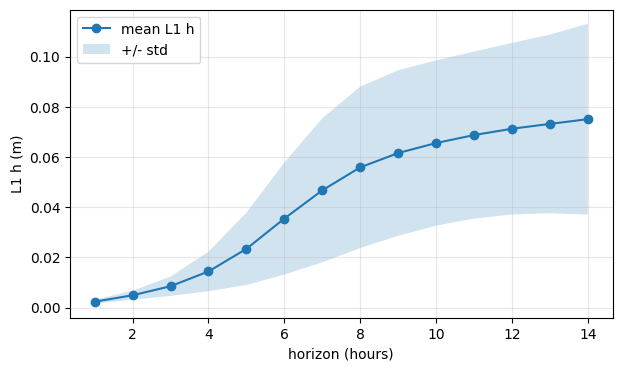

In [6]:
hours = [row["hours"] for row in rows]
mean_h = [row["l1_mean_h"] for row in rows]
std_h = [row["l1_std_h"] for row in rows]

lower = np.asarray(mean_h) - np.asarray(std_h)
upper = np.asarray(mean_h) + np.asarray(std_h)

plt.figure(figsize=FIGSIZE)
plt.plot(hours, mean_h, marker="o", label="mean L1 h")
plt.fill_between(hours, lower, upper, alpha=0.2, label="+/- std")
plt.xlabel("horizon (hours)")
plt.ylabel("L1 h (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [7]:
import matplotlib.tri as mtri

from python.create_dgl_dataset import add_mesh_info
from python.python_code.data_manip.extraction.telemac_file import TelemacFile

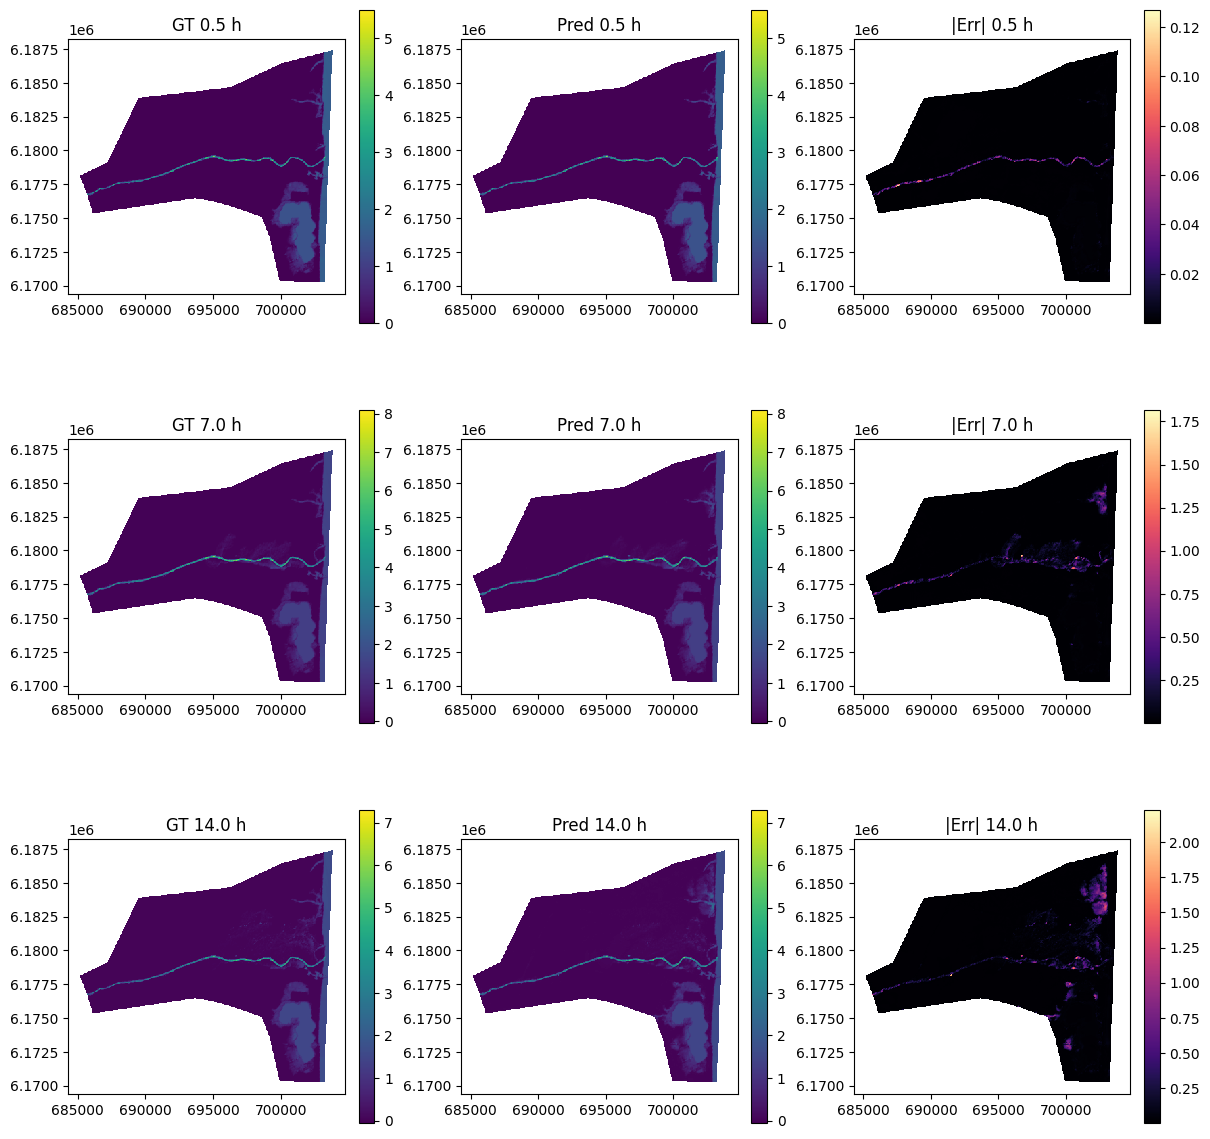

In [9]:
SEQUENCE_INDEX = 2
REGULAR_MESH_SLF = "/work/m24046/m24046mrcr/Test_Tet_regular/Tet_regular_50m.slf"

mesh = TelemacFile(REGULAR_MESH_SLF)
xy, triangles = add_mesh_info(mesh)
triangulation = mtri.Triangulation(xy[:, 0], xy[:, 1], triangles)

graphs = dataset[SEQUENCE_INDEX]
steps_to_plot = [1, max(1, (len(graphs) - 1) // 2), len(graphs) - 1]

state = create_rollout_state(graphs[0], context)
snapshots = {}

for step in range(1, max(steps_to_plot) + 1):
    x_gt_full_n = graphs[step].ndata["x"][:, context.dyn_start:context.dyn_start + context.dyn_len].to(context.device)
    x_gt = denormalize_state(x_gt_full_n[:, :3], context)
    q_t1_n = x_gt_full_n[:, 3:4] if MODEL_CONFIG["use_q_feature"] else None

    result = rollout_step(
        model=model,
        state=state,
        context=context,
        x_gt=x_gt,
        q_t1_n=q_t1_n,
    )

    if step in steps_to_plot:
        snapshots[step] = {
            "gt_h": result.target_state[:, 0].detach().cpu().numpy(),
            "pred_h": result.predicted_state[:, 0].detach().cpu().numpy(),
        }

    state = result.next_state

fig, axes = plt.subplots(3, 3, figsize=(12, 12), constrained_layout=True)

for row, step in enumerate(steps_to_plot):
    gt_h = snapshots[step]["gt_h"]
    pred_h = snapshots[step]["pred_h"]
    err_h = np.abs(pred_h - gt_h)

    vmin = float(min(gt_h.min(), pred_h.min()))
    vmax = float(max(gt_h.max(), pred_h.max()))
    hours = step * MODEL_CONFIG["dt_seconds"] / 3600.0

    plots = [
        (f"GT {hours:.1f} h", gt_h, "viridis", vmin, vmax),
        (f"Pred {hours:.1f} h", pred_h, "viridis", vmin, vmax),
        (f"|Err| {hours:.1f} h", err_h, "magma", None, None),
    ]

    for col, (title, values, cmap, pmin, pmax) in enumerate(plots):
        artist = axes[row, col].tripcolor(
            triangulation,
            values,
            shading="flat",
            cmap=cmap,
            vmin=pmin,
            vmax=pmax,
        )
        axes[row, col].set_title(title)
        axes[row, col].set_aspect("equal")
        fig.colorbar(artist, ax=axes[row, col], shrink=0.8)

plt.show()